<a href="https://colab.research.google.com/github/amosagekouassi-source/DI-Bootcamp/blob/master/XP_TimeSeries_LSTM_Student.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Exercises XP: Time Series with LSTM

This is a guided notebook for the exercise on the platform. Cells marked **PREFILLED** are for execution only. Cells marked **To-Do** require your action. When a written answer is required, the **To-Do** appears inside a markdown cell. When code is required, the **To-Do** appears inside a code cell as comments.

Learning points appear for important concepts.

## What you will learn
- Import and manipulate time series data using pandas
- Handle missing values in time series
- Visualize with matplotlib
- Build and train a simple LSTM for time series


## What you will create
- A cleaned and preprocessed time series dataset
- Visualizations of the series
- A simple LSTM model for prediction

# Part 1: Data Import and Initial Exploration

**Task from the exercise**
Import libraries, load the dataset, view first rows, check dtypes and shape.

**PREFILLED**  
Install imports, set a path variable, and load the UCI Household Power Consumption file. The file is usually semicolon separated with `?` as missing.

In [24]:
# PREFILLED: just execute
%matplotlib inline
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

pd.set_option('display.max_columns', 100)

# Define the path to your uploaded local file
DATA_PATH = Path('household_power_consumption.txt')

if DATA_PATH.exists():
    # Specify numeric columns and load the CSV with semicolon separator
    parse_cols = {'Global_active_power': 'float64', 'Global_reactive_power': 'float64', 'Voltage': 'float64', 'Global_intensity': 'float64', 'Sub_metering_1': 'float64', 'Sub_metering_2': 'float64', 'Sub_metering_3': 'float64'}
    usecols = ['Date','Time'] + list(parse_cols.keys())

    # Load the data
    df = pd.read_csv(DATA_PATH, sep=';', na_values=['?'], usecols=usecols, dtype=parse_cols, dayfirst=True)

    # Create a proper Datetime index
    df['Datetime'] = pd.to_datetime(df['Date'] + ' ' + df['Time'])
    df = df.set_index('Datetime').drop(['Date', 'Time'], axis=1).sort_index()

    print('Dataset loaded successfully from local file.')
    print('Shape:', df.shape)
    display(df.head())
else:
    print(f'Error: Local file {DATA_PATH} not found. Please ensure it is uploaded to the root directory.')

Dataset loaded successfully from local file.
Shape: (32193, 7)


/tmp/ipykernel_1337/1259120726.py:22: UserWarning: Parsing dates in %d/%m/%Y %H:%M:%S format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df['Datetime'] = pd.to_datetime(df['Date'] + ' ' + df['Time'])


,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3
Datetime,,,,,,,
2006-12-16 17:24:00,4.216,0.418,234.84,18.4,0.0,1.0,17.0
2006-12-16 17:25:00,5.360,0.436,233.63,23.0,0.0,1.0,16.0
2006-12-16 17:26:00,5.374,0.498,233.29,23.0,0.0,2.0,17.0
2006-12-16 17:27:00,5.388,0.502,233.74,23.0,0.0,1.0,17.0
2006-12-16 17:28:00,3.666,0.528,235.68,15.8,0.0,1.0,17.0


# Part 2: Handling Missing Values

**Task from the exercise**
Identify columns with missing values. Fill missing values using the mean of each column. Verify there are no missing values left.

**To-Do (code):** Compute a missing value summary, then fill numeric columns with their mean. Recheck for remaining NaNs.

In [25]:
# Show missing values summary
missing_before = df.isna().sum()
print('Missing values per column:\n', missing_before[missing_before > 0])

# Impute missing values using column means
df = df.fillna(df.mean())

# Verify imputation
print('Total missing values after imputation:', df.isna().sum().sum())

Missing values per column:
 Global_active_power      4
Global_reactive_power    4
Voltage                  4
Global_intensity         4
Sub_metering_1           4
Sub_metering_2           5
Sub_metering_3           5
dtype: int64
Total missing values after imputation: 0


# Part 3: Data Visualization

**Task from the exercise**
Resample the `Global_active_power` column over a day and plot the sum and mean. Plot the mean and standard deviation of `Global_intensity` resampled over a day.

**PREFILLED**  
Helper plotting functions using matplotlib.

In [26]:
# PREFILLED: just execute
def plot_daily_sum_and_mean(series, title_prefix='Global_active_power'):
    daily = series.resample('1D')
    s = daily.sum(min_count=1)
    m = daily.mean()

    # Plot Sum
    plt.figure(figsize=(8,3))
    plt.plot(s.index, s.values)
    plt.title(f'{title_prefix} daily sum')
    plt.xlabel('date')
    plt.ylabel('sum')
    plt.tight_layout()
    plt.show() # Forced display

    # Plot Mean
    plt.figure(figsize=(8,3))
    plt.plot(m.index, m.values)
    plt.title(f'{title_prefix} daily mean')
    plt.xlabel('date')
    plt.ylabel('mean')
    plt.tight_layout()
    plt.show() # Forced display

def plot_daily_mean_std(series, title_prefix='Global_intensity'):
    daily = series.resample('1D')
    m = daily.mean()
    sd = daily.std()

    plt.figure(figsize=(8,3))
    plt.plot(m.index, m.values, label='mean')
    plt.plot(sd.index, sd.values, label='std')
    plt.title(f'{title_prefix} daily mean and std')
    plt.xlabel('date')
    plt.ylabel('value')
    plt.legend()
    plt.tight_layout()
    plt.show() # Forced display

**To-Do (code):** Call the helpers on the required columns. If a plot seems too dense, slice a recent time window.

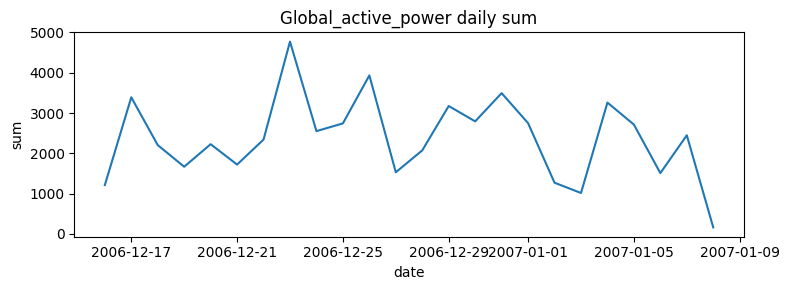

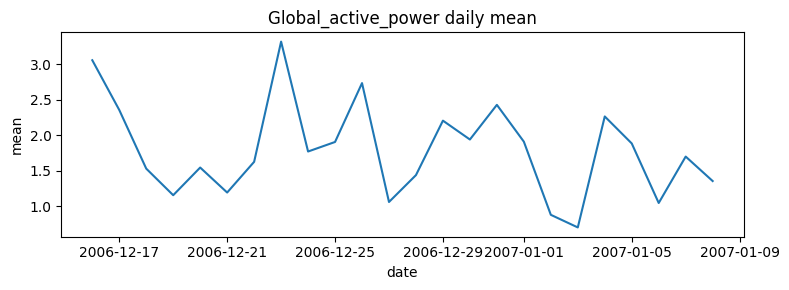

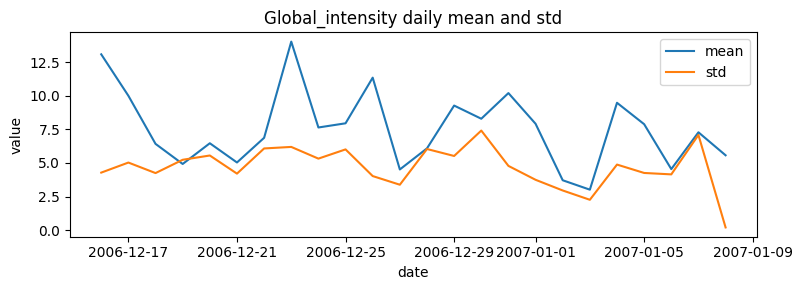

In [27]:
# Call the plotting helpers for Global active power and Global intensity
# English comment: Execute visualization helpers
plot_daily_sum_and_mean(df['Global_active_power'], title_prefix='Global_active_power')
plot_daily_mean_std(df['Global_intensity'], title_prefix='Global_intensity')

# Part 4: Data Preprocessing for LSTM

**Task from the exercise**
Normalize the dataset, split into train and test, and reshape for LSTM input.

**Learning point**  
LSTMs consume sequences with shape [batch, time, features]. You must build sliding windows. Use a lookback window and predict the next step.

![image.png](https://github.com/user-attachments/assets/be3e815f-2aff-4e8d-ac48-eca27b1c729c)

**PREFILLED**  
Windowing helpers and a train test split by time.

In [28]:
from sklearn.preprocessing import MinMaxScaler

# Function to create sliding window sequences
def make_windows(arr_2d, window=48, horizon=1):
    X, y = [], []
    for i in range(len(arr_2d) - window - horizon + 1):
        X.append(arr_2d[i:i+window])
        y.append(arr_2d[i+window:i+window+horizon, 0])
    return np.asarray(X, dtype=np.float32), np.asarray(y, dtype=np.float32)

# Function for chronological data splitting
def time_train_test_split(df, split_ratio=0.8):
    k = int(len(df) * split_ratio)
    return df.iloc[:k].copy(), df.iloc[k:].copy()

# Scaling and preprocessing pipeline
feat_cols = ['Global_active_power','Global_reactive_power','Voltage','Global_intensity','Sub_metering_1','Sub_metering_2','Sub_metering_3']
df_tr, df_te = time_train_test_split(df[feat_cols], split_ratio=0.8)

scaler = MinMaxScaler()
tr_scaled = scaler.fit_transform(df_tr.values)
te_scaled = scaler.transform(df_te.values)

# Configure window parameters
WINDOW, HORIZON = 48, 1
X_tr, y_tr = make_windows(tr_scaled, WINDOW, HORIZON)
X_te, y_te = make_windows(te_scaled, WINDOW, HORIZON)

print('Data ready:', X_tr.shape, X_te.shape)

Data ready: (25706, 48, 7) (6391, 48, 7)



**Target Selection:**
We are predicting `Global_active_power` (the first column) because it represents the total active power consumed by the household, which is the primary variable of interest for load forecasting. We use the other columns as features to provide more context to the LSTM model.

# Part 5: Building an LSTM Model

**Task from the exercise**
Import the libraries, define the LSTM architecture, and compile with a suitable loss and optimizer.

**To-Do (code):** Build a small LSTM with one or two LSTM layers and a Dense output of size `HORIZON`. Use `mse` loss and `adam` optimizer. Print `model.summary()`.

In [29]:
import tensorflow as tf
from tensorflow.keras import layers, models

# Define the LSTM architecture using the window and feature size
# WINDOW is 48, features is 7
model = models.Sequential([
    layers.Input(shape=(WINDOW, X_tr.shape[-1])),
    layers.LSTM(64, return_sequences=False),
    layers.Dense(HORIZON)
])

# Compile the model with Adam and MSE
model.compile(optimizer='adam', loss='mse', metrics=['mae'])
model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_2 (LSTM)                   │ (None, 64)             │        18,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 18,497 (72.25 KB)

 Trainable params: 18,497 (72.25 KB)

 Non-trainable params: 0 (0.00 B)

# Part 6: Training and Evaluating the LSTM Model

**Task from the exercise**
Train the model, evaluate on the test set, and plot training and validation loss.

**PREFILLED**  
Callbacks and plotting helper. You supply the model and data in the To-Do cell.

In [30]:
# PREFILLED: just execute
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

def fit_and_plot(model, X_tr, y_tr, X_te, y_te, epochs=10, batch=256):
    es = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)
    rl = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=2)
    h = model.fit(X_tr, y_tr, validation_data=(X_te, y_te),
                  epochs=epochs, batch_size=batch, callbacks=[es, rl], verbose=2)
    plt.figure(figsize=(6,4))
    plt.plot(h.history['loss'], label='loss')
    plt.plot(h.history['val_loss'], label='val_loss')
    plt.title('Training and validation loss')
    plt.xlabel('epoch'); plt.ylabel('loss'); plt.legend(); plt.tight_layout(); plt.show()
    return h

**To-Do (code):** Train and evaluate. Report final test MAE and MSE.

Epoch 1/15
101/101 - 2s - 21ms/step - loss: 0.0114 - mae: 0.0651 - val_loss: 0.0024 - val_mae: 0.0258 - learning_rate: 0.0010
Epoch 2/15
101/101 - 1s - 7ms/step - loss: 0.0034 - mae: 0.0328 - val_loss: 0.0018 - val_mae: 0.0213 - learning_rate: 0.0010
Epoch 3/15
101/101 - 1s - 8ms/step - loss: 0.0030 - mae: 0.0306 - val_loss: 0.0015 - val_mae: 0.0179 - learning_rate: 0.0010
Epoch 4/15
101/101 - 1s - 8ms/step - loss: 0.0028 - mae: 0.0285 - val_loss: 0.0015 - val_mae: 0.0182 - learning_rate: 0.0010
Epoch 5/15
101/101 - 1s - 8ms/step - loss: 0.0027 - mae: 0.0280 - val_loss: 0.0013 - val_mae: 0.0171 - learning_rate: 0.0010
Epoch 6/15
101/101 - 1s - 8ms/step - loss: 0.0026 - mae: 0.0268 - val_loss: 0.0013 - val_mae: 0.0153 - learning_rate: 0.0010
Epoch 7/15
101/101 - 1s - 8ms/step - loss: 0.0025 - mae: 0.0264 - val_loss: 0.0012 - val_mae: 0.0166 - learning_rate: 0.0010
Epoch 8/15
101/101 - 1s - 7ms/step - loss: 0.0024 - mae: 0.0258 - val_loss: 0.0012 - val_mae: 0.0170 - learning_rate: 0.0010

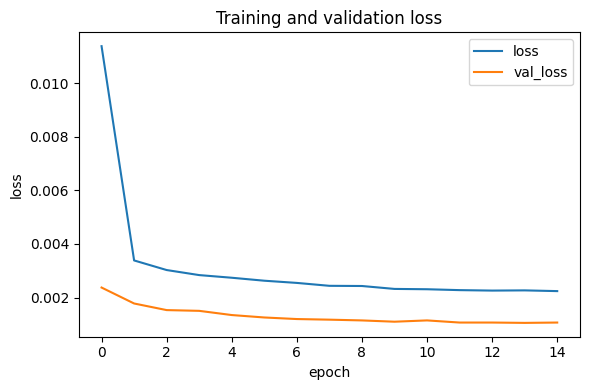

Test MSE: 0.00106
Test MAE: 0.01377


In [31]:
# Train the model using the fit_and_plot helper function
# Make sure you have executed the PREFILLED cell in Part 6 first
history = fit_and_plot(model, X_tr, y_tr, X_te, y_te, epochs=15, batch=256)

# Evaluate the model on the test set
results = model.evaluate(X_te, y_te, verbose=0)
print(f'Test MSE: {results[0]:.5f}')
print(f'Test MAE: {results[1]:.5f}')